#  Model Experiments

This notebook trains and compares models for predicting voluntary insurance enrollment. It uses the project modules for data loading, validation, leakage-safe splitting, preprocessing, and evaluation.





## Setup

In [25]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier

from src.data.load_data import DataLoader, DataSplits
from src.evaluation.evaluate import classification_metrics
from src.features.preprocessing import build_preprocessor
from src.utils.config import CONFIG
from src.utils.seed import set_seed

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

set_seed(CONFIG.data.random_state)

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = CONFIG.data.target_column
ID_COLUMN = CONFIG.data.id_column
RANDOM_STATE = CONFIG.data.random_state

PROJECT_ROOT

WindowsPath('d:/Projects/insurance-enrollment-prediction')

## 1. Load and Split Data

The data split is handled by `DataLoader`. It validates the raw data first, then creates stratified train, validation, and test splits on complete rows. Preprocessing is not fitted before the split.

In [3]:
loader = DataLoader()
raw_data = loader.load_data()
loader.validate_data(raw_data)
splits: DataSplits = loader.split_data(raw_data)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(splits.train), len(splits.validation), len(splits.test)],
        "enrolled_rate": [
            splits.y_train.mean(),
            splits.y_validation.mean(),
            splits.y_test.mean(),
        ],
    }
)

print(f"Raw data shape: {raw_data.shape}")
display(split_summary)
display(splits.X_train.head())

2026-08-23 19:46:06 | INFO | src.data.load_data | Loading data from D:\Projects\insurance-enrollment-prediction\data\raw\employee_data.csv
2026-08-23 19:46:06 | INFO | src.data.load_data | Data loaded successfully: 10000 rows, 10 columns
2026-08-23 19:46:06 | INFO | src.data.load_data | Data validation completed.
2026-08-23 19:46:06 | INFO | src.data.load_data | Data split completed: train=6000, validation=2000, test=2000


Raw data shape: (10000, 10)


,split,rows,enrolled_rate
0,train,6000,0.6173
1,validation,2000,0.6175
2,test,2000,0.6175


,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years
0,41,Male,Married,48878.1800,Full-time,West,Yes,5.3000
1,52,Female,Married,53258.6100,Full-time,South,Yes,4.9000
2,36,Female,Divorced,70308.4600,Full-time,South,Yes,0.8000
3,23,Female,Single,71843.6900,Full-time,Northeast,No,2.8000
4,47,Other,Divorced,55029.6700,Part-time,South,No,2.0000


## 2. Leakage Audit

Before training,check the most common leakage issues:

- The target column should not be present in feature matrices.
- The identifier column should not be present in feature matrices.
- Employee IDs should not overlap across train, validation, and test row splits.
- The target rate should be similar across splits because the split is stratified.
- Preprocessing should be fitted inside each model pipeline, not on the full dataset.

In [4]:
feature_columns = set(splits.X_train.columns)

leakage_checks = {
    "target_removed_from_X_train": TARGET not in feature_columns,
    "id_removed_from_X_train": ID_COLUMN not in feature_columns,
    "train_validation_id_overlap": len(set(splits.train[ID_COLUMN]) & set(splits.validation[ID_COLUMN])),
    "train_test_id_overlap": len(set(splits.train[ID_COLUMN]) & set(splits.test[ID_COLUMN])),
    "validation_test_id_overlap": len(set(splits.validation[ID_COLUMN]) & set(splits.test[ID_COLUMN])),
}

leakage_checks

{'target_removed_from_X_train': True,
 'id_removed_from_X_train': True,
 'train_validation_id_overlap': 0,
 'train_test_id_overlap': 0,
 'validation_test_id_overlap': 0}

In [5]:
split_summary.assign(
    enrolled_rate_diff_from_train=lambda data: (
        data["enrolled_rate"] - data.loc[data["split"] == "train", "enrolled_rate"].iloc[0]
    ).abs()
)

,split,rows,enrolled_rate,enrolled_rate_diff_from_train
0,train,6000,0.6173,0.0000
1,validation,2000,0.6175,0.0002
2,test,2000,0.6175,0.0002


## 3. Preprocessing Pipeline

The preprocessing pipeline comes from `src.features.preprocessing`. It performs row-level feature engineering and then applies numeric and categorical transformations.



In [6]:
preview_preprocessor = build_preprocessor()
engineered_sample = preview_preprocessor.named_steps["feature_engineering"].transform(
    splits.train.head(5)
)

print("Preprocessor steps:", [name for name, _ in preview_preprocessor.steps])
print(f"Engineered preview columns: {engineered_sample.shape[1]}")
display(engineered_sample.head())

2026-08-23 19:47:01 | INFO | src.features.preprocessing | Building preprocessing pipeline with 5 numeric and 11 categorical features.


Preprocessor steps: ['feature_engineering', 'column_preprocessing']
Engineered preview columns: 16


,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,salary_per_age,tenure_to_age_ratio,age_group,salary_band,tenure_band,dependents_employment_type,dependents_salary_band,age_dependents_group
0,41,Male,Married,48878.1800,Full-time,West,Yes,5.3000,1192.1507,0.1293,40s,low_salary,established,Yes_Full-time,Yes_low_salary,40s_Yes
1,52,Female,Married,53258.6100,Full-time,South,Yes,4.9000,1024.2040,0.0942,50s,mid_salary,established,Yes_Full-time,Yes_mid_salary,50s_Yes
2,36,Female,Divorced,70308.4600,Full-time,South,Yes,0.8000,1953.0128,0.0222,30s,high_salary,new_hire,Yes_Full-time,Yes_high_salary,30s_Yes
3,23,Female,Single,71843.6900,Full-time,Northeast,No,2.8000,3123.6387,0.1217,under_30,high_salary,early_tenure,No_Full-time,No_high_salary,under_30_No
4,47,Other,Divorced,55029.6700,Part-time,South,No,2.0000,1170.8440,0.0426,40s,mid_salary,early_tenure,No_Part-time,No_mid_salary,40s_No


## 4. Train Models

The earlier tree models can look like they are overfitting because the synthetic data contains very strong rules: dependents, employment type, salary, and age almost separate the target. To make the comparison more defensible, the tree models below are deliberately regularized.



In [26]:


def build_model_pipeline(classifier) -> Pipeline:
    """Attach a fresh engineered feature preprocessor to each classifier."""
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("classifier", classifier),
        ]
    )


# 1. Define XGBoost & SGD Logistic Regression Models
sgd_xgb_models = {
    "logistic_regression_sgd": build_model_pipeline(
        SGDClassifier(
            loss="log_loss",  
            penalty="l2",
            alpha=0.0001,
            max_iter=2000,
            tol=1e-3,
            class_weight="balanced",
            early_stopping=True,
            n_iter_no_change=10,
            random_state=RANDOM_STATE,
        )
    ),
    "xgboost_regularized": build_model_pipeline(
        XGBClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),
}

# 2. Train Models
for model_name, model in sgd_xgb_models.items():
    print(f"Training {model_name}...")
    model.fit(splits.X_train, splits.y_train)

print(f"Successfully trained {len(sgd_xgb_models)} models.")

2026-08-23 20:38:10 | INFO | src.features.preprocessing | Building preprocessing pipeline with 5 numeric and 11 categorical features.
2026-08-23 20:38:10 | INFO | src.features.preprocessing | Building preprocessing pipeline with 5 numeric and 11 categorical features.


Training logistic_regression_sgd...
Training xgboost_regularized...
Successfully trained 2 models.


In [7]:
def build_model_pipeline(classifier) -> Pipeline:
    """Attach a fresh preprocessor to each classifier."""
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("classifier", classifier),
        ]
    )


models = {
    "logistic_regression": build_model_pipeline(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "random_forest_regularized": build_model_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=30,
            min_samples_split=80,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),
    "gradient_boosting_regularized": build_model_pipeline(
        GradientBoostingClassifier(
            n_estimators=120,
            learning_rate=0.05,
            max_depth=2,
            subsample=0.8,
            random_state=RANDOM_STATE,
        )
    ),
}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(splits.X_train, splits.y_train)

print(f"Trained {len(models)} models.")

2026-08-23 19:47:46 | INFO | src.features.preprocessing | Building preprocessing pipeline with 5 numeric and 11 categorical features.
2026-08-23 19:47:46 | INFO | src.features.preprocessing | Building preprocessing pipeline with 5 numeric and 11 categorical features.
2026-08-23 19:47:46 | INFO | src.features.preprocessing | Building preprocessing pipeline with 5 numeric and 11 categorical features.


Training logistic_regression...
Training random_forest_regularized...
Training gradient_boosting_regularized...
Trained 3 models.


## 5. Evaluate Train and Validation Performance

Overfitting is not just high accuracy. A better check is whether training performance is much higher than validation performance. Large train-validation gaps suggest memorization or overly flexible models.

In [8]:
def evaluate_split(model, X, y, split_name: str, model_name: str) -> dict:
    """Score a fitted model and return one flat metrics record."""
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    metrics = classification_metrics(y, y_pred, y_proba)
    return {"model": model_name, "split": split_name, **metrics}


evaluation_records = []
for model_name, model in models.items():
    evaluation_records.append(
        evaluate_split(model, splits.X_train, splits.y_train, "train", model_name)
    )
    evaluation_records.append(
        evaluate_split(
            model,
            splits.X_validation,
            splits.y_validation,
            "validation",
            model_name,
        )
    )

metrics_df = pd.DataFrame(evaluation_records)
metrics_df

,model,split,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,train,0.9642,0.9834,0.9582,0.9706,0.9940
1,logistic_regression,validation,0.9645,0.9842,0.9579,0.9709,0.9939
2,random_forest_regularized,train,0.9955,0.9928,1.0000,0.9964,1.0000
3,random_forest_regularized,validation,0.9955,0.9936,0.9992,0.9964,1.0000
4,gradient_boosting_regularized,train,1.0000,1.0000,1.0000,1.0000,1.0000
5,gradient_boosting_regularized,validation,0.9995,1.0000,0.9992,0.9996,1.0000


In [24]:
# 1. Collect Metrics on Train and Validation Splits
evaluation_records_new = []

for model_name, model in sgd_xgb_models.items():
    evaluation_records_new.append(
        evaluate_split(
            model, splits.X_train, splits.y_train, "train", model_name
        )
    )
    evaluation_records_new.append(
        evaluate_split(
            model,
            splits.X_validation,
            splits.y_validation,
            "validation",
            model_name,
        )
    )

new_metrics_df = pd.DataFrame(evaluation_records_new)
display(new_metrics_df)

# 2. Compute Generalization Gap (Train vs. Validation)
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
val_metrics_new = (
    new_metrics_df[new_metrics_df["split"] == "validation"]
    .set_index("model")[metric_cols]
)
train_metrics_new = (
    new_metrics_df[new_metrics_df["split"] == "train"]
    .set_index("model")[metric_cols]
)

overfit_gap_new = (train_metrics_new - val_metrics_new).add_suffix(
    "_train_minus_val"
)

print("--- Generalization Gap (Train - Validation) ---")
display(overfit_gap_new)

,model,split,accuracy,precision,recall,f1,roc_auc
0,logistic_regression_sgd,train,0.9463,0.9807,0.9314,0.9554,0.9900
1,logistic_regression_sgd,validation,0.9460,0.9804,0.9312,0.9551,0.9900
2,xgboost_regularized,train,0.9993,0.9997,0.9992,0.9995,1.0000
3,xgboost_regularized,validation,0.9985,1.0000,0.9976,0.9988,1.0000


--- Generalization Gap (Train - Validation) ---


,accuracy_train_minus_val,precision_train_minus_val,recall_train_minus_val,f1_train_minus_val,roc_auc_train_minus_val
model,,,,,
logistic_regression_sgd,0.0003,0.0003,0.0003,0.0003,0.0000
xgboost_regularized,0.0008,-0.0003,0.0016,0.0007,0.0000


In [9]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
validation_metrics = metrics_df[metrics_df["split"] == "validation"].set_index("model")[metric_cols]
train_metrics = metrics_df[metrics_df["split"] == "train"].set_index("model")[metric_cols]

overfit_gap = (train_metrics - validation_metrics).add_suffix("_train_minus_validation")
overfit_gap

,accuracy_train_minus_validation,precision_train_minus_validation,recall_train_minus_validation,f1_train_minus_validation,roc_auc_train_minus_validation
model,,,,,
logistic_regression,-0.0003,-0.0008,0.0003,-0.0003,0.0001
random_forest_regularized,0.0000,-0.0008,0.0008,0.0000,0.0000
gradient_boosting_regularized,0.0005,0.0000,0.0008,0.0004,0.0000


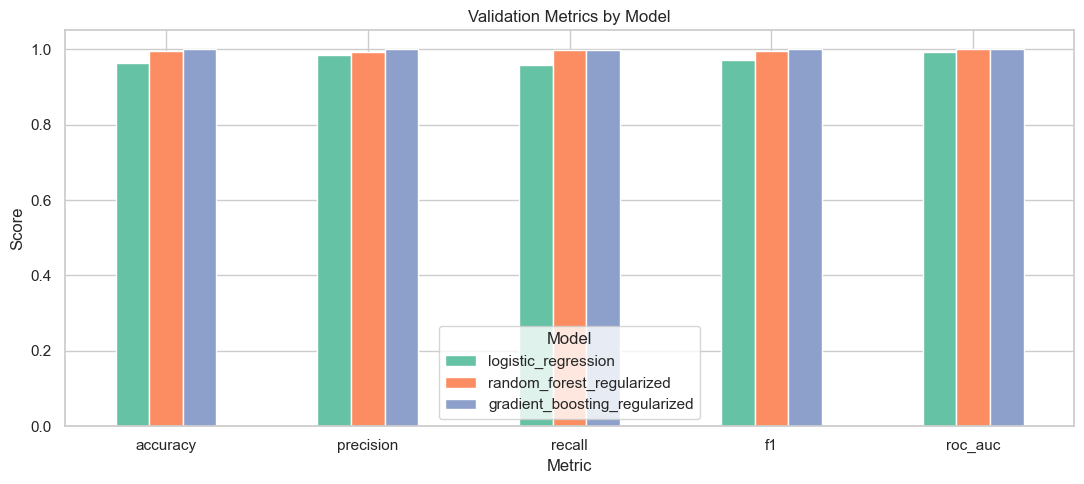

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
validation_metrics.T.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Validation Metrics by Model")
ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.legend(title="Model")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison_validation_metrics.png", dpi=150)
plt.show()

## 6. Confusion Matrices

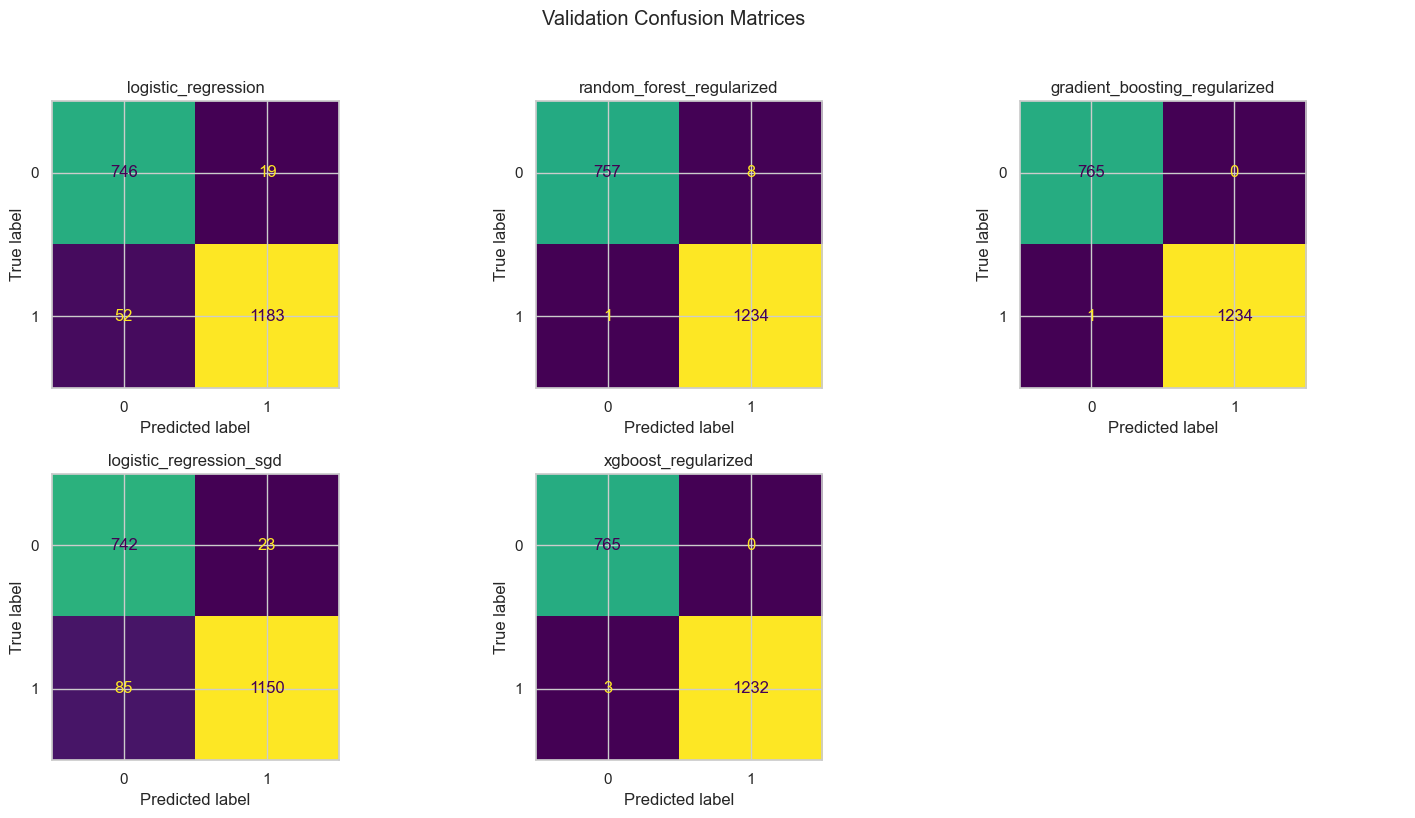

In [27]:
comparison_models = {**models, **sgd_xgb_models}

n_models = len(comparison_models)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (model_name, model) in zip(axes, comparison_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        splits.y_validation,
        model.predict(splits.X_validation),
        ax=ax,
        colorbar=False,
    )
    ax.set_title(model_name)

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Validation Confusion Matrices", y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison_confusion_matrices.png", dpi=150)
plt.show()


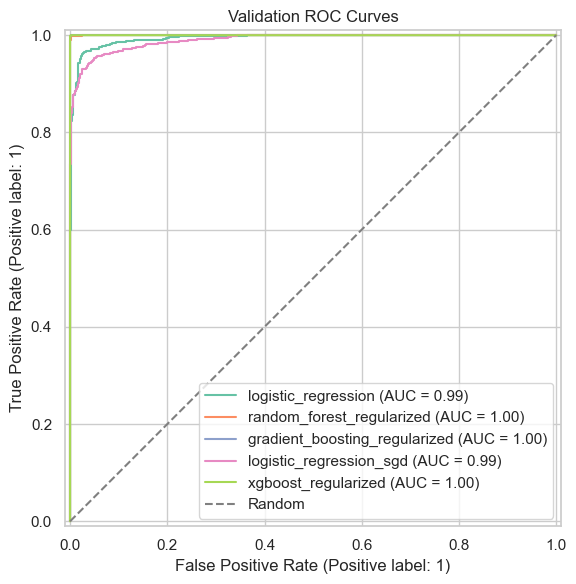

In [28]:
comparison_models = {**models, **sgd_xgb_models}

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model in comparison_models.items():
    RocCurveDisplay.from_predictions(
        splits.y_validation,
        model.predict_proba(splits.X_validation)[:, 1],
        name=model_name,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("Validation ROC Curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison_roc_curves.png", dpi=150)
plt.show()


## Final Summary

This notebook compares several supervised binary classification models for predicting voluntary insurance enrollment. The experiments use a leakage-safe workflow: the data is split before preprocessing, `employee_id` and `enrolled` are removed from the feature matrix, and each model receives its own sklearn pipeline with feature engineering, imputation, scaling, and one-hot encoding fitted only on the training split.

The models tested are logistic regression, regularized random forest, regularized gradient boosting, SGD logistic regression, and regularized XGBoost. Logistic regression and SGD logistic regression provide interpretable linear baselines. Random forest, gradient boosting, and XGBoost test whether tree-based models can capture stronger non-linear relationships and feature interactions in the tabular data.

On the validation split, logistic regression performs strongly with an F1 score of 0.9709 and ROC-AUC of 0.9939. SGD logistic regression is slightly weaker, with an F1 score of 0.9551 and ROC-AUC of 0.9900. The tree-based models perform best overall: regularized random forest reaches an F1 score of 0.9964, regularized XGBoost reaches 0.9988, and regularized gradient boosting reaches the highest validation F1 score of 0.9996.

The confusion matrices and ROC curves show that all models separate the classes well, but the boosted tree models make the fewest validation errors and produce near-perfect ROC curves. The train-validation gaps are also very small, which suggests the high scores are not caused by obvious overfitting inside this notebook workflow.

The final takeaway is that logistic regression is a useful benchmark because it is simple, fast, and explainable, while XGBoost is a strong production candidate because it gives near-best validation performance, handles non-linear interactions, supports regularization, and integrates cleanly with the project pipeline.